Project -Digit recognition by CNN

In [1]:
import pandas as pd
import numpy as np
from tensorflow.keras.datasets import mnist
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPool2D,Dense,Flatten,Dropout


In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


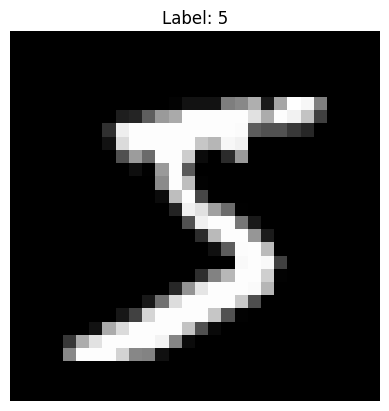

In [3]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

In [4]:
X_train=X_train/255.0
X_test=X_test/255.0

In [5]:
X_train=X_train.reshape(-1,28,28,1)
X_test=X_test.reshape(-1,28,28,1)
print(X_train.shape)

(60000, 28, 28, 1)


In [6]:
CNN_model =Sequential([
    Conv2D(32,kernel_size=(3,3), activation="relu", input_shape=(28,28,1)),
    MaxPool2D(pool_size=(2,2)),
    
    Conv2D(64, kernel_size=(3,3), activation="relu"),
    MaxPool2D(pool_size=(2,2)),
    
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10,activation="softmax")
])

c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
CNN_model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [8]:
history =CNN_model.fit(X_train,y_train,epochs=5,batch_size=32,validation_data=[X_test,y_test],verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 17ms/step - accuracy: 0.9311 - loss: 0.2271 - val_accuracy: 0.9839 - val_loss: 0.0502
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9754 - loss: 0.0844 - val_accuracy: 0.9873 - val_loss: 0.0372
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9816 - loss: 0.0626 - val_accuracy: 0.9890 - val_loss: 0.0348
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9849 - loss: 0.0499 - val_accuracy: 0.9894 - val_loss: 0.0303
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9872 - loss: 0.0418 - val_accuracy: 0.9914 - val_loss: 0.0245


In [9]:
acc_cnn = CNN_model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9914 - loss: 0.0245
